<a href="https://colab.research.google.com/github/JhonatanMotaDev/EDA_LICA/blob/main/EDA_LICA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados a partir do conjunto de dados "Carga de Energia Diária" do ONS

## Objetivo

Esta análise exploratória procura investigar o comportamento da carga de energia elétrica nos subsistemas brasileiros utilizando dados disponibilizados pelo Operador Nacional do Sistema Elétrico (ONS).

Pergunta principal: Quais padrões temporais e diferenças regionais podem ser observados na carga de energia elétrica dos subsistemas brasileiros ao longo do período analisado?

O foco da análise está na identificação de:

- padrões temporais
- tendências
- sazonalidade
- diferenças entre subsistemas
- anomalias

## Configuração Inicial e Funções de Pré-processamento

In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("colorblind")
plt.style.use("default")

def preprocess_data(df_input):
    df = df_input.copy()
    df['din_instante'] = pd.to_datetime(df['din_instante'])

    df['ano'] = df['din_instante'].dt.year
    df['mes'] = df['din_instante'].dt.month

    dias_traduzidos = {
        'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
        'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
    }
    df['dia_semana'] = df['din_instante'].dt.day_name().map(dias_traduzidos)

    ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
    df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=ordem_dias, ordered=True)

    df['is_weekend'] = df['din_instante'].dt.dayofweek >= 5

    return df.dropna(subset=['val_cargaenergiamwmed'])

### Carregamento e Preparação Inicial dos Dados

In [3]:
PATH = '../data/raw/CARGA_ENERGIA_2026.csv'
df_raw = pd.read_csv(PATH, sep=';', encoding='latin1')

df = preprocess_data(df_raw)

print(f"Dados carregados: {df.shape[0]} registros processados.")
display(df.head())

Dados carregados: 520 registros processados.


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed,ano,mes,dia_semana,is_weekend
0,N,Norte,2026-01-01,7649.438875,2026,1,Quinta,False
1,NE,Nordeste,2026-01-01,12269.972583,2026,1,Quinta,False
2,S,Sul,2026-01-01,11203.195917,2026,1,Quinta,False
3,SE,Sudeste/Centro-Oeste,2026-01-01,40463.793500,2026,1,Quinta,False
4,N,Norte,2026-01-02,8235.208333,2026,1,Sexta,False


# Dados carregados, primeiro contato

Nesta etapa estão sendo interpretados:

- estrutura do dataset
- dimensões
- tipos das variáveis
- possíveis inconsistências

In [4]:
print(f"=== PAINEL DE DIAGNÓSTICO DO DATASET ===")
print(f"Total de registros: {df.shape[0]}")
print(f"Colunas disponíveis: {df.shape[1]}\n")

print("--- Estrutura Técnica ---")
df.info()

print("\n--- Resumo Estatístico da Carga (MWmed) ---")
stats = df['val_cargaenergiamwmed'].describe().to_frame().transpose()
display(stats.round(2))

print("\n--- Período de Tempo Analisado ---")
print(f"Início: {df['din_instante'].min().strftime('%d/%m/%Y')}")
print(f"Fim:    {df['din_instante'].max().strftime('%d/%m/%Y')}")

=== PAINEL DE DIAGNÓSTICO DO DATASET ===
Total de registros: 520
Colunas disponíveis: 8

--- Estrutura Técnica ---
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_subsistema          520 non-null    str           
 1   nom_subsistema         520 non-null    str           
 2   din_instante           520 non-null    datetime64[us]
 3   val_cargaenergiamwmed  520 non-null    float64       
 4   ano                    520 non-null    int32         
 5   mes                    520 non-null    int32         
 6   dia_semana             520 non-null    category      
 7   is_weekend             520 non-null    bool          
dtypes: bool(1), category(1), datetime64[us](1), float64(1), int32(2), str(2)
memory usage: 21.8 KB

--- Resumo Estatístico da Carga (MWmed) ---


,count,mean,std,min,25%,50%,75%,max
val_cargaenergiamwmed,520.0,20745.83,15006.19,7556.8,8866.34,14022.69,23667.95,52569.94



--- Período de Tempo Analisado ---
Início: 01/01/2026
Fim:    10/05/2026


# Avaliação da qualidade dos dados

Agora serão verificados:
- valores ausentes
- valores duplicados
- se os registros são consistentes
- se existem valores inválidos

In [5]:
print("=== AVALIAÇÃO DE QUALIDADE DOS DADOS ===")

nulos = df.isnull().sum().sum()
print(f"\nValores ausentes encontrados: {nulos}")
if nulos > 0:
    display(df.isnull().sum())

duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

dataset_dias = (df['din_instante'].max() - df['din_instante'].min()).days + 1
print(f"Amplitude temporal: {dataset_dias} dias")

negativos = (df['val_cargaenergiamwmed'] < 0).sum()
print(f"Valores de carga negativos ou inválidos: {negativos}")

print("\nStatus: Dados validados e prontos para análise.")

=== AVALIAÇÃO DE QUALIDADE DOS DADOS ===

Valores ausentes encontrados: 0
Registros duplicados: 0
Amplitude temporal: 130 dias
Valores de carga negativos ou inválidos: 0

Status: Dados validados e prontos para análise.


### **Compreensão das Variáveis**

O dataset após o pré-processamento contém as seguintes variáveis principais encontradas:

*   **`din_instante` (Data):** Marca o tempo do registro. Essencial para identificar tendências ao longo de períodos de tempo e sazonalidade.

*   **`nom_subsistema` (Região):** Variável categórica (Norte, Nordeste, Sul, Sudeste/Centro-Oeste). Permite comparar o consumo entre diferentes regiões do Brasil.

*   **`val_cargaenergiamwmed` (Carga):** Nossa variável alvo (Numérica Contínua). Representa a demanda média de energia em MWmed.

**Variáveis adicionadas posteriormente**
*   **`dia_semana` (Categórica):** Traduzida para português e ordenada (Segunda a Domingo). Excelente para analisar o comportamento em dias úteis em comparação com fins de semana.
*   **`mes` / `ano` (Temporal):** Extraídos para facilitar agrupamentos mensais e anuais.
*   **`is_weekend` (Booleana):** Flag que identifica se o registro pertence a um final de semana, permitindo análises rápidas de impacto da carga industrial no consumo de energia.

## Análise da Distribuição Regional dos Dados

In [6]:
print("=== DISTRIBUIÇÃO REGIONAL (SUBSISTEMAS) ===")

contagem_regional = df['nom_subsistema'].value_counts().to_frame()
contagem_regional.columns = ['Total de Registros']
display(contagem_regional)

print(f"\nObservação: O dataset está perfeitamente equilibrado com {contagem_regional.iloc[0,0]} dias para cada região.")

=== DISTRIBUIÇÃO REGIONAL (SUBSISTEMAS) ===


,Total de Registros
nom_subsistema,
Norte,130
Nordeste,130
Sul,130
Sudeste/Centro-Oeste,130



Observação: O dataset está perfeitamente equilibrado com 130 dias para cada região.


# Análise univariada

Agora a distribuição da variável de carga energética será analisada.

In [7]:
print("=== ESTATÍSTICA DESCRITIVA DA CARGA (MWmed) ===")

descritiva = df['val_cargaenergiamwmed'].describe().to_frame().T
display(descritiva.round(2))

skewness = df['val_cargaenergiamwmed'].skew()
print(f"\nAssimetria (Skewness): {skewness:.2f}")
print("Nota: Uma assimetria positiva alta indica que a maioria do tempo a carga está em níveis baixos/médios, com picos extremos as vezes.")

=== ESTATÍSTICA DESCRITIVA DA CARGA (MWmed) ===


,count,mean,std,min,25%,50%,75%,max
val_cargaenergiamwmed,520.0,20745.83,15006.19,7556.8,8866.34,14022.69,23667.95,52569.94



Assimetria (Skewness): 1.08
Nota: Uma assimetria positiva alta indica que a maioria do tempo a carga está em níveis baixos/médios, com picos extremos as vezes.


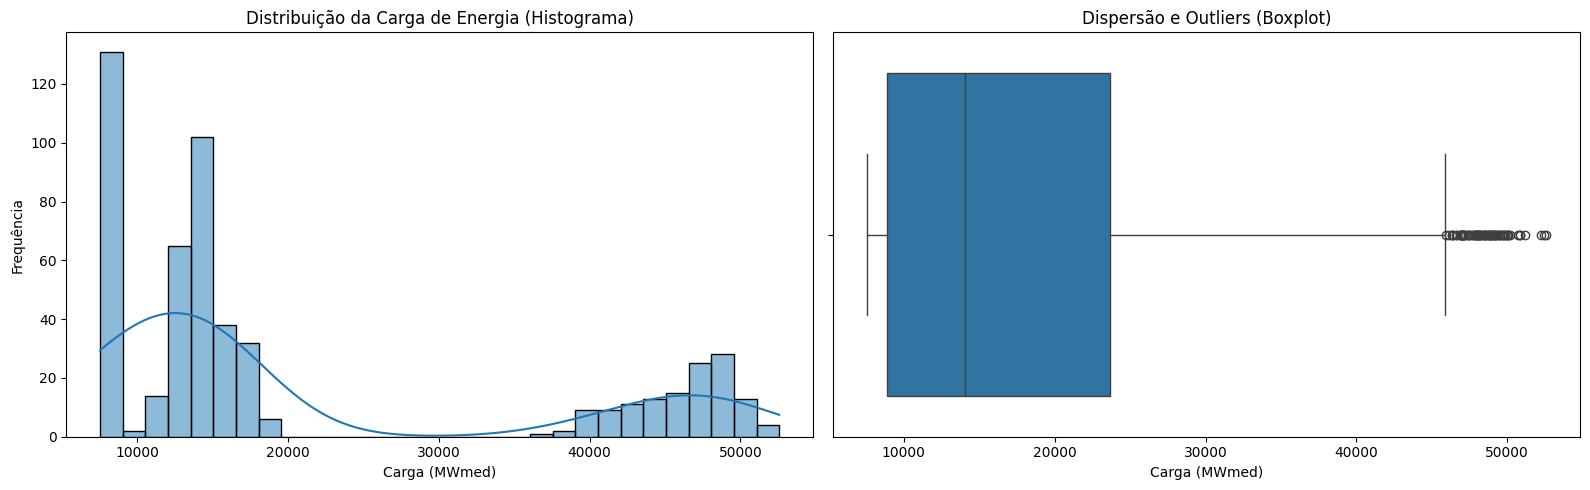

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['val_cargaenergiamwmed'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Distribuição da Carga de Energia (Histograma)')
ax[0].set_xlabel('Carga (MWmed)')
ax[0].set_ylabel('Frequência')

sns.boxplot(x=df['val_cargaenergiamwmed'], ax=ax[1])
ax[1].set_title('Dispersão e Outliers (Boxplot)')
ax[1].set_xlabel('Carga (MWmed)')

plt.tight_layout()
plt.savefig('../reports/figures/univariada_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

### **Achados da Análise Univariada**

* **Amplitude:** A carga varia de aproximadamente 7,5k a 52,5k MWmed.

* **Distribuição:** Observam-se uma distribuição multimodal ou fortemente enviesada à direita. Isso ocorre porque o consumo varia drasticamente entre os subsistemas (o Sudeste consome muito mais que o Norte, por exemplo).

* **Outliers:** O boxplot indica a presença de valores na extremidade superior, que representam os picos de demanda máxima no subsistema mais pesado (Sudeste/Centro-Oeste).

# Análise temporal

Analise do comportamento da carga energética ao longo do tempo.

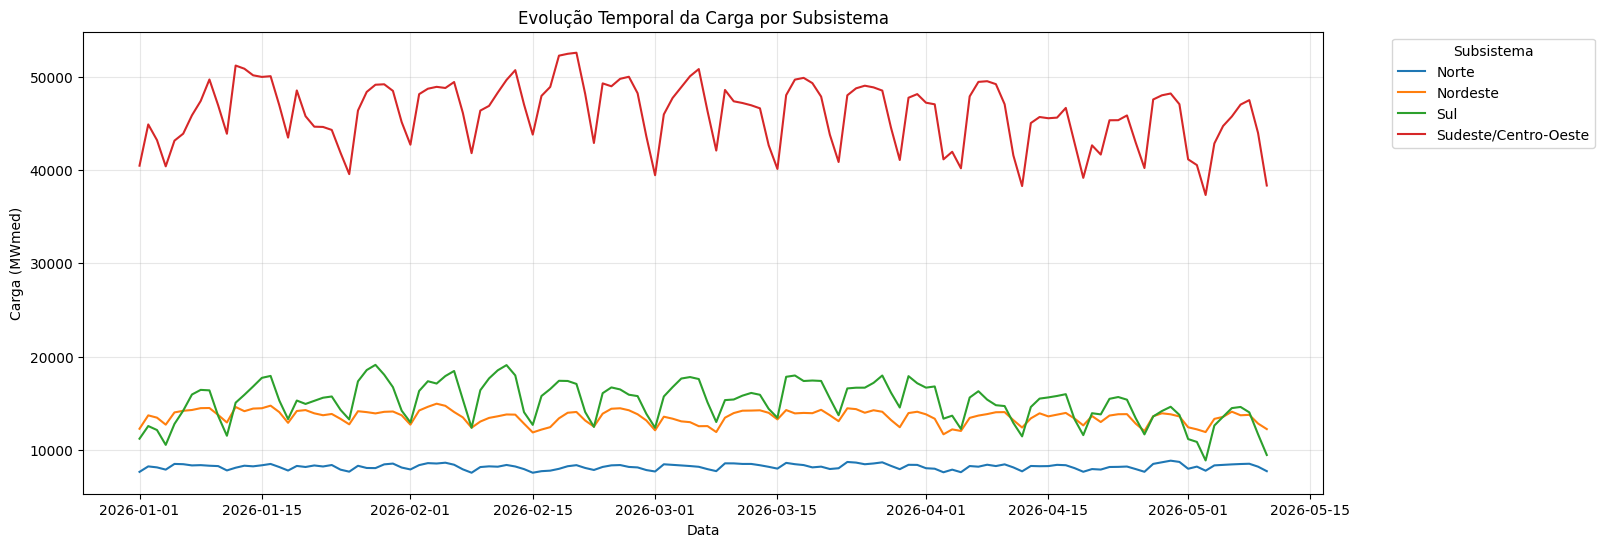

In [9]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x='din_instante', y='val_cargaenergiamwmed', hue='nom_subsistema')
plt.title('Evolução Temporal da Carga por Subsistema')
plt.xlabel('Data')
plt.ylabel('Carga (MWmed)')
plt.grid(True, alpha=0.3)
plt.legend(title='Subsistema', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('../reports/figures/temporal_carga_subsistema.png', dpi=150, bbox_inches='tight')
plt.show()

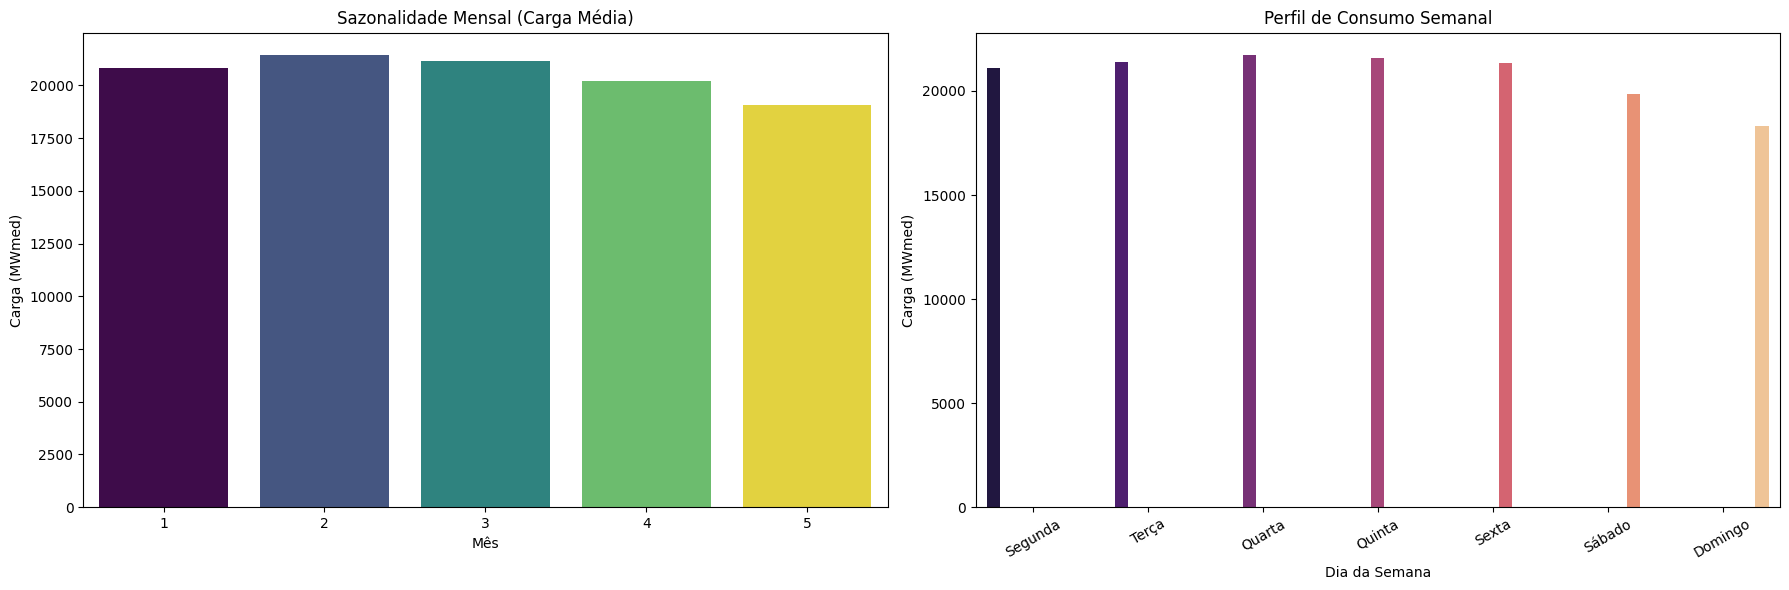

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

monthly_avg = df.groupby('mes')['val_cargaenergiamwmed'].mean().reset_index()
sns.barplot(ax=ax[0], data=monthly_avg, x='mes', y='val_cargaenergiamwmed', palette='viridis', hue='mes', legend=False)
ax[0].set_title('Sazonalidade Mensal (Carga Média)')
ax[0].set_ylabel('Carga (MWmed)')
ax[0].set_xlabel('Mês')

weekly_avg = df.groupby('dia_semana', observed=True)['val_cargaenergiamwmed'].mean().reset_index()
sns.barplot(ax=ax[1], data=weekly_avg, x='dia_semana', y='val_cargaenergiamwmed', palette='magma', hue='dia_semana', legend=False)
ax[1].set_title('Perfil de Consumo Semanal')
ax[1].set_ylabel('Carga (MWmed)')
ax[1].set_xlabel('Dia da Semana')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/temporal_perfil_semanal.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise Multivariada

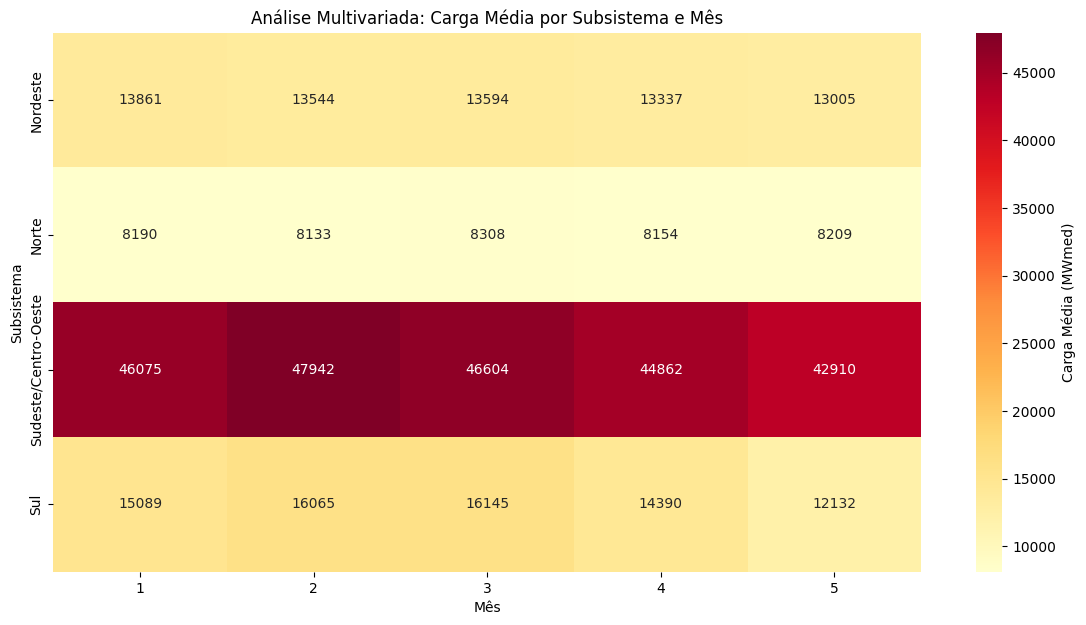

In [11]:
pivot_table = df.pivot_table(
    values='val_cargaenergiamwmed',
    index='nom_subsistema',
    columns='mes',
    aggfunc='mean'
)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Carga Média (MWmed)'})
plt.title('Análise Multivariada: Carga Média por Subsistema e Mês')
plt.xlabel('Mês')
plt.ylabel('Subsistema')
plt.savefig('../reports/figures/multivariada_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificação de Anomalias

In [12]:
def detect_outliers_grouped(group):
    Q1 = group['val_cargaenergiamwmed'].quantile(0.25)
    Q3 = group['val_cargaenergiamwmed'].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR

    return group[(group['val_cargaenergiamwmed'] < low) | (group['val_cargaenergiamwmed'] > high)]

outliers_refined = df.groupby('nom_subsistema', group_keys=False).apply(detect_outliers_grouped, include_groups=False).reset_index(drop=True)

print(f'=== RELATÓRIO DE ANOMALIAS ===')
print(f'Total de anomalias detectadas: {len(outliers_refined)}')
if len(outliers_refined) > 0:
    display(outliers_refined[['din_instante', 'val_cargaenergiamwmed']])

=== RELATÓRIO DE ANOMALIAS ===
Total de anomalias detectadas: 1


,din_instante,val_cargaenergiamwmed
0,2026-05-03,8872.575375


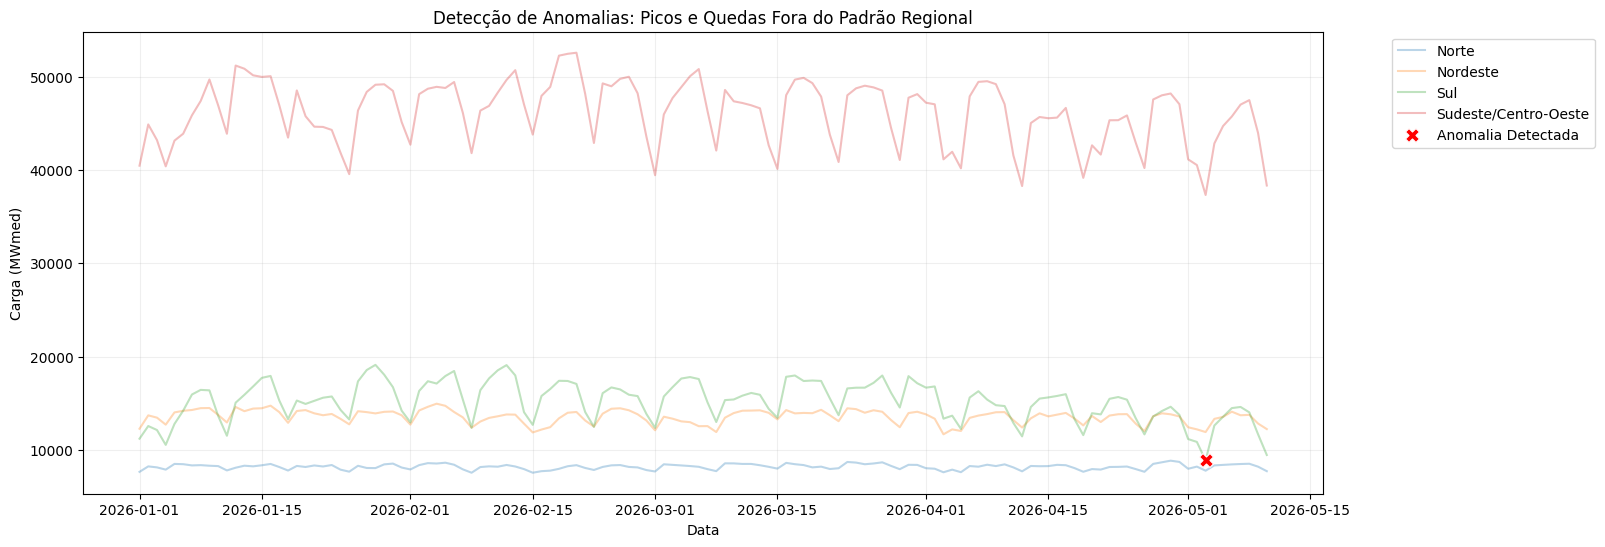

In [13]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=df, x='din_instante', y='val_cargaenergiamwmed', hue='nom_subsistema', alpha=0.3)

if not outliers_refined.empty:
    sns.scatterplot(data=outliers_refined, x='din_instante', y='val_cargaenergiamwmed',
                    color='red', s=100, label='Anomalia Detectada', zorder=5, marker='X')

plt.title('Detecção de Anomalias: Picos e Quedas Fora do Padrão Regional')
plt.xlabel('Data')
plt.ylabel('Carga (MWmed)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.savefig('../reports/figures/anomalias_deteccao.png', dpi=150, bbox_inches='tight')
plt.show()

## Análise da Disparidade de Carga entre os Subsistemas

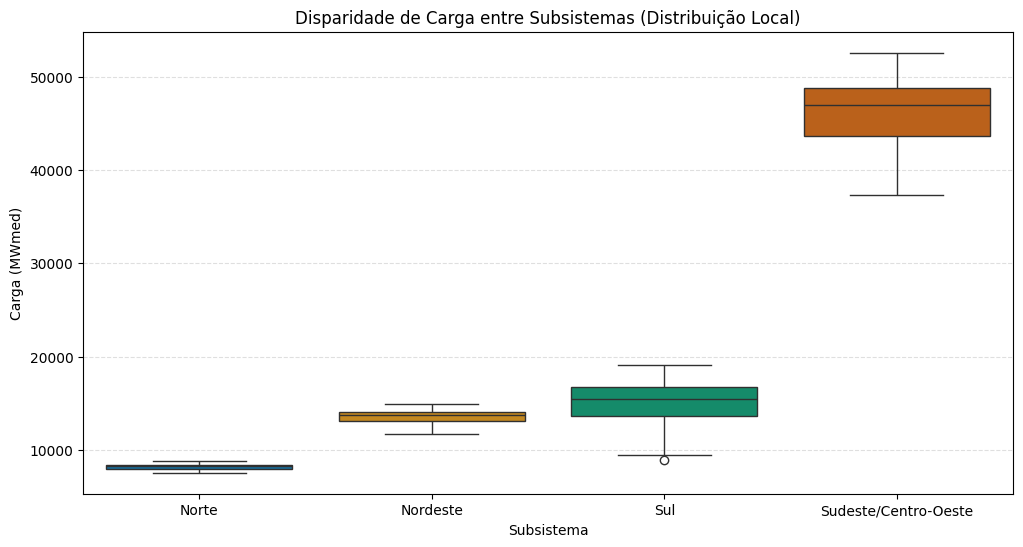

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='nom_subsistema', y='val_cargaenergiamwmed', palette='colorblind', hue='nom_subsistema', legend=False)
plt.title('Disparidade de Carga entre Subsistemas (Distribuição Local)')
plt.xlabel('Subsistema')
plt.ylabel('Carga (MWmed)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('../reports/figures/disparidade_subsistemas.png', dpi=150, bbox_inches='tight')
plt.show()

## **Conclusões e Insights Finais**

A partir da exploração dos dados de carga de energia do ONS para o primeiro quadrimestre de 2026, foram consolidados os seguintes pontos estratégicos para análises futuras por exemplo:

### **1. Disparidade Estrutural Regional**
*   **Predomínio do Sudeste/Centro-Oeste:** Esta região atua como o centro de carga do país, com demanda média superior a **45.000 MWmed**, o que representa mais que o triplo dos outros subsistemas. Sua alta variabilidade (vistas no Boxplot e Heatmap) indica uma rede mais complexa e sensível a mudanças.

*   **Estabilidade no Norte:** O subsistema Norte apresenta o perfil mais estável e de menor carga, sugerindo uma demanda menos elástica a variações de temperatura ou ciclos semanais agressivos.

### **2. Ciclos Operacionais e Econômicos**
*   **Efeito Fim de Semana:** Observamos uma queda acentuada de aproximadamente **15% a 20% na carga aos domingos**. Esse padrão é um forte indicador da dependência da carga em relação à atividade industrial e comercial de grande porte.

*   **Pico Sazonal Típico:** Os picos de demanda em **fevereiro e março** alinham-se ao comportamento histórico brasileiro, onde as altas temperaturas de verão elevam o uso de climatização, pressionando o Sistema Interligado Nacional (SIN).

### **3. Qualidade dos Dados e Observabilidade**
*   **Confiabilidade:** O dataset demonstrou alta integridade, sem falhas de registro ou duplicidade.


*   **Anomalias Identificadas:** A detecção de um ponto atípico no Sul em maio(queda brusca) serve de alerta para eventos pontuais (como manutenções nos sistemaas de distribuição de energia ou variações climáticas extremas), mas que não alteram a tendência de crescimento/estabilidade regional ao fim da análise.